Final Model

In [ ]:
import glob
import pickle
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

radar_dir = "./radar_pcd_frames_15P"
depth_gt_path = "./BeamSteering GroundTruth/15p_2.pkl"


NUM_RANGE_BINS = 256
W = 128
H = NUM_RANGE_BINS
RANGE_RESOLUTION_M = 0.043
MAX_RANGE_M = RANGE_RESOLUTION_M * NUM_RANGE_BINS
X_MIN_M, X_MAX_M = -5.0, 5.0


def normalize_data(images):
    """Proper normalization to [-1, 1] range for tanh activation"""
    images = images.astype(np.float32)
    return (images - 0.5) * 2.0

def augment_data(radar_batch, depth_batch):
    """Data augmentation with proper random operations"""
    if tf.random.uniform(()) > 0.5:
        radar_batch = tf.image.flip_left_right(radar_batch)
        depth_batch = tf.image.flip_left_right(depth_batch)
    
    noise = tf.random.normal(tf.shape(radar_batch), stddev=0.01)
    radar_batch = radar_batch + noise
    radar_batch = tf.clip_by_value(radar_batch, -1.0, 1.0)
    
    return radar_batch, depth_batch


print("Loading radar data...")
radar_files = sorted(glob.glob(os.path.join(radar_dir, "frame_*_image.npy")))
print("Found radar image frames:", len(radar_files))

radar_imgs_list = []
for f in radar_files:
    img = np.load(f)
    radar_imgs_list.append(img.astype(np.float32))

radar_imgs = np.stack(radar_imgs_list, axis=0)  
radar_imgs = radar_imgs[..., None]              
print("Radar imgs shape:", radar_imgs.shape)

print("Loading depth data...")
with open(depth_gt_path, "rb") as f:
    depth_data = pickle.load(f)
print("Loaded depth entries:", len(depth_data))

def depth_pcd_to_bev(pcd, H_bev=H, W_bev=W, x_range=(X_MIN_M, X_MAX_M), height_min=-0.2, height_max=0.2):
    """Convert depth point cloud to BEV occupancy grid"""
    X = pcd['f0']  
    Y = pcd['f1']  
    Z = pcd['f2']  

    mask = (X >= x_range[0]) & (X <= x_range[1]) & \
           (Z >= 0.0) & (Z <= MAX_RANGE_M) & \
           (Y >= height_min) & (Y <= height_max)
    
    X = X[mask]
    Z = Z[mask]

    bev = np.zeros((H_bev, W_bev), dtype=np.float32)

    if X.size == 0:
        return bev

    # Convert to pixel coordinates
    x_bins = np.linspace(x_range[0], x_range[1], W_bev)
    z_idx = (Z / RANGE_RESOLUTION_M).astype(int)
    x_idx = np.digitize(X, x_bins) - 1

    valid = (x_idx >= 0) & (x_idx < W_bev) & (z_idx >= 0) & (z_idx < H_bev)
    
    # Gaussian smoothing instead of binary for better training
    for x, z in zip(x_idx[valid], z_idx[valid]):
        for dz in [-1, 0, 1]:
            for dx in [-1, 0, 1]:
                nz, nx = z + dz, x + dx
                if 0 <= nz < H_bev and 0 <= nx < W_bev:
                    weight = 0.8 if dz == 0 and dx == 0 else 0.2
                    bev[nz, nx] = max(bev[nz, nx], weight)
    
    return np.clip(bev, 0, 1)

depth_images_raw = []
for pcd, t in depth_data:
    depth_images_raw.append(depth_pcd_to_bev(pcd, H_bev=H, W_bev=W))

depth_images_raw = np.array(depth_images_raw)   
depth_imgs = depth_images_raw[..., None]        
print("Depth images shape:", depth_imgs.shape)

print("Synchronizing frames...")

num_radar = len(radar_imgs)
num_depth = len(depth_imgs)

if num_depth < num_radar:
    print(f"Warning: Only {num_depth} depth frames for {num_radar} radar frames.")
    print("Using repeating depth frames with interpolation...")
    
    repeat_factor = num_radar // num_depth
    remainder = num_radar % num_depth
    
    repeated_depth = []
    for i in range(repeat_factor):
        repeated_depth.extend(depth_imgs)
    if remainder > 0:
        repeated_depth.extend(depth_imgs[:remainder])  
    depth_imgs = np.array(repeated_depth)
else:
    depth_imgs = depth_imgs[:num_radar]

print("After sync - Radar shape:", radar_imgs.shape)
print("After sync - Depth shape:", depth_imgs.shape)

# ====================
# Data Normalization
# ====================
print("Normalizing data...")
radar_imgs = normalize_data(radar_imgs)
depth_imgs = normalize_data(depth_imgs)

BATCH_SIZE = 8  
EPOCHS = 2     
LEARNING_RATE = 1e-4  

print("Creating dataset...")
dataset = tf.data.Dataset.from_tensor_slices((radar_imgs, depth_imgs))
dataset = dataset.map(augment_data, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

total_samples = len(radar_imgs)
train_size = int(0.8 * total_samples)
val_size = total_samples - train_size

train_dataset = dataset.take(train_size // BATCH_SIZE)
val_dataset = dataset.skip(train_size // BATCH_SIZE)

print(f"Training samples: {train_size}, Validation samples: {val_size}")

def build_improved_generator(input_shape=(H, W, 1)):
    inputs = layers.Input(shape=input_shape)
    
    x = layers.Conv2D(64, 7, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Downsampling
    d1 = x  
    
    x = layers.Conv2D(128, 3, strides=2, padding='same')(x) 
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    d2 = x
    
    x = layers.Conv2D(256, 3, strides=2, padding='same')(x)  
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    d3 = x
    
    x = layers.Conv2D(512, 3, strides=2, padding='same')(x)  
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    for _ in range(6):
        shortcut = x
        x = layers.Conv2D(512, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(512, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Add()([x, shortcut])
        x = layers.ReLU()(x)
    
    # Upsampling with skip connections
    x = layers.Conv2DTranspose(256, 3, strides=2, padding='same')(x)  
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Concatenate()([x, d3])
    
    x = layers.Conv2DTranspose(128, 3, strides=2, padding='same')(x)  
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Concatenate()([x, d2])
    
    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same')(x)   
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Concatenate()([x, d1])
    
    # Final layers
    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    outputs = layers.Conv2D(1, 7, padding='same', activation='tanh')(x)
    
    return Model(inputs, outputs, name="improved_generator")

def build_improved_discriminator(input_shape=(H, W, 1)):
    inp = layers.Input(shape=input_shape, name="radar_input")
    tar = layers.Input(shape=input_shape, name="depth_target")
    
    x = layers.Concatenate()([inp, tar])  
    
    def add_discriminator_block(x, filters, strides=2):
        x = layers.Conv2D(filters, 4, strides=strides, padding='same')(x)
        x = layers.LeakyReLU(0.2)(x)
        x = layers.Dropout(0.3)(x)  
        return x
    
    x = add_discriminator_block(x, 64, strides=2)
    x = add_discriminator_block(x, 128, strides=2)
    x = add_discriminator_block(x, 256, strides=2)
    x = add_discriminator_block(x, 512, strides=1)  
    
    x = layers.Conv2D(1, 4, strides=1, padding='same')(x)
    
    return Model([inp, tar], x, name="improved_discriminator")

print("Building models...")
generator = build_improved_generator(input_shape=(H, W, 1))
discriminator = build_improved_discriminator(input_shape=(H, W, 1))

bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(disc_fake, gen_output, target, lambda_L1=100.0, lambda_ssim=1.0):
    gan_loss = bce(tf.ones_like(disc_fake), disc_fake)
    l1_loss = tf.reduce_mean(tf.abs(target - gen_output))
    
    target_01 = (target + 1) / 2
    gen_output_01 = (gen_output + 1) / 2
    ssim_loss = 1 - tf.reduce_mean(tf.image.ssim(target_01, gen_output_01, max_val=1.0))
    
    total_loss = gan_loss + lambda_L1 * l1_loss + lambda_ssim * ssim_loss
    return total_loss, gan_loss, l1_loss, ssim_loss

def discriminator_loss(disc_real, disc_fake):
    real_loss = bce(tf.ones_like(disc_real), disc_real)
    fake_loss = bce(tf.zeros_like(disc_fake), disc_fake)
    return (real_loss + fake_loss) * 0.5  

gen_optimizer = tf.keras.optimizers.Adam(LEARNING_RATE, beta_1=0.5, beta_2=0.999)
disc_optimizer = tf.keras.optimizers.Adam(LEARNING_RATE * 2, beta_1=0.5, beta_2=0.999)  

@tf.function
def train_step(radar_batch, depth_batch):
    with tf.GradientTape(persistent=True) as tape:
        gen_output = generator(radar_batch, training=True)
        
        disc_real = discriminator([radar_batch, depth_batch], training=True)
        disc_fake = discriminator([radar_batch, gen_output], training=True)

        gen_total_loss, gen_gan_loss, gen_l1_loss, gen_ssim_loss = generator_loss(
            disc_fake, gen_output, depth_batch, lambda_L1=100.0, lambda_ssim=1.0
        )
        disc_loss = discriminator_loss(disc_real, disc_fake)
    
    gen_grads = tape.gradient(gen_total_loss, generator.trainable_variables)
    disc_grads = tape.gradient(disc_loss, discriminator.trainable_variables)
    
    gen_optimizer.apply_gradients(zip(gen_grads, generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))
    
    return {
        "gen_total": gen_total_loss,
        "gen_gan": gen_gan_loss,
        "gen_l1": gen_l1_loss,
        "gen_ssim": gen_ssim_loss,
        "disc": disc_loss
    }

def calculate_iou(y_true, y_pred, threshold=0.0):
    """Calculate IoU for normalized data in [-1,1] range"""
    y_true = (y_true + 1) / 2  # Convert to [0,1]
    y_pred = (y_pred + 1) / 2
    
    y_true = tf.cast(y_true > threshold, tf.float32)
    y_pred = tf.cast(y_pred > threshold, tf.float32)
    
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    
    return intersection / (union + 1e-7)

def evaluate_model(generator, dataset, num_batches=5):
    total_iou = 0.0
    count = 0
    
    for radar_batch, depth_batch in dataset.take(num_batches):
        pred = generator(radar_batch, training=False)
        batch_iou = calculate_iou(depth_batch, pred)
        total_iou += batch_iou
        count += 1
    
    return total_iou / count if count > 0 else 0.0

print("Starting training...")
best_iou = 0.0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    
    epoch_losses = {"gen_total": 0, "gen_gan": 0, "gen_l1": 0, "gen_ssim": 0, "disc": 0}
    num_batches = 0
    
    for step, (radar_batch, depth_batch) in enumerate(train_dataset):
        losses = train_step(radar_batch, depth_batch)
        
        for key in epoch_losses:
            epoch_losses[key] += losses[key]
        num_batches += 1
        
        if step % 20 == 0:
            print(f"  Step {step}: G_total={losses['gen_total']:.4f}, "
                  f"G_L1={losses['gen_l1']:.4f}, D={losses['disc']:.4f}")
    
    for key in epoch_losses:
        epoch_losses[key] /= num_batches
    
    val_iou = evaluate_model(generator, val_dataset)
    
    print(f"  Epoch Summary:")
    print(f"  G_total={epoch_losses['gen_total']:.4f} | "
          f"G_L1={epoch_losses['gen_l1']:.4f} | "
          f"G_GAN={epoch_losses['gen_gan']:.4f} | "
          f"G_SSIM={epoch_losses['gen_ssim']:.4f} | "
          f"D={epoch_losses['disc']:.4f} | Val_IoU={val_iou:.4f}")
    
    if val_iou > best_iou:
        best_iou = val_iou
        generator.save("best_generator.h5")
        print(f"  ✓ Saved new best model with IoU: {val_iou:.4f}")
    
    if epoch_losses['disc'] < 0.1 and epoch > 10:
        print("  Early stopping: Discriminator too weak")
        break

generator.save("final_generator_.h5")

print(f"\nTraining completed! Best IoU: {best_iou:.4f}")

TensorFlow version: 2.20.0
Loading radar data...
Found radar image frames: 500
Radar imgs shape: (500, 256, 128, 1)
Loading depth data...
Loaded depth entries: 50
Depth images shape: (50, 256, 128, 1)
Synchronizing frames...
Using repeating depth frames with interpolation...
After sync - Radar shape: (500, 256, 128, 1)
After sync - Depth shape: (500, 256, 128, 1)
Normalizing data...
Creating dataset...
Training samples: 400, Validation samples: 100
Building models...
Starting training...

Epoch 1/2
  Step 0: G_total=100.8095, G_L1=0.9911, D=0.6938
  Step 20: G_total=18.4220, G_L1=0.1652, D=0.5269
  Step 40: G_total=11.8949, G_L1=0.1046, D=0.5479


  Epoch Summary:
  G_total=23.7213 | G_L1=0.2179 | G_GAN=1.0906 | G_SSIM=0.8385 | D=0.5841 | Val_IoU=0.0293
  ✓ Saved new best model with IoU: 0.0293

Epoch 2/2
  Step 0: G_total=9.6596, G_L1=0.0803, D=0.5284
  Step 20: G_total=7.9443, G_L1=0.0630, D=0.4982
  Step 40: G_total=8.0197, G_L1=0.0572, D=0.5134


  Epoch Summary:
  G_total=7.9657 | G_L1=0.0628 | G_GAN=1.3971 | G_SSIM=0.2883 | D=0.5462 | Val_IoU=0.0294


  ✓ Saved new best model with IoU: 0.0294

Training completed! Best IoU: 0.0294



=== Loading data for angle -15° ===
Loaded 500 radar frames from ./radar_pcd_frames_15N
  Common frames for -15°: 50

=== Loading data for angle 0° ===
Loaded 500 radar frames from ./radar_pcd_frames_1
  Common frames for 0°: 50

=== Loading data for angle +15° ===
Loaded 500 radar frames from ./radar_pcd_frames_15P
  Common frames for +15°: 50

Global minimum common frames across all angles: 50
Requested idx=120 is out of range. Using 49 instead.
Using frame index: 49
Loading model for -15°: ./final_generator_improved_15N.h5


Loading model for 0°: ./final_generator_improved.h5


Loading model for +15°: ./final_generator_improved_15P.h5


Saved: beam_angle_output\2_fusion_vs_0deg_idx49_300dpi.png


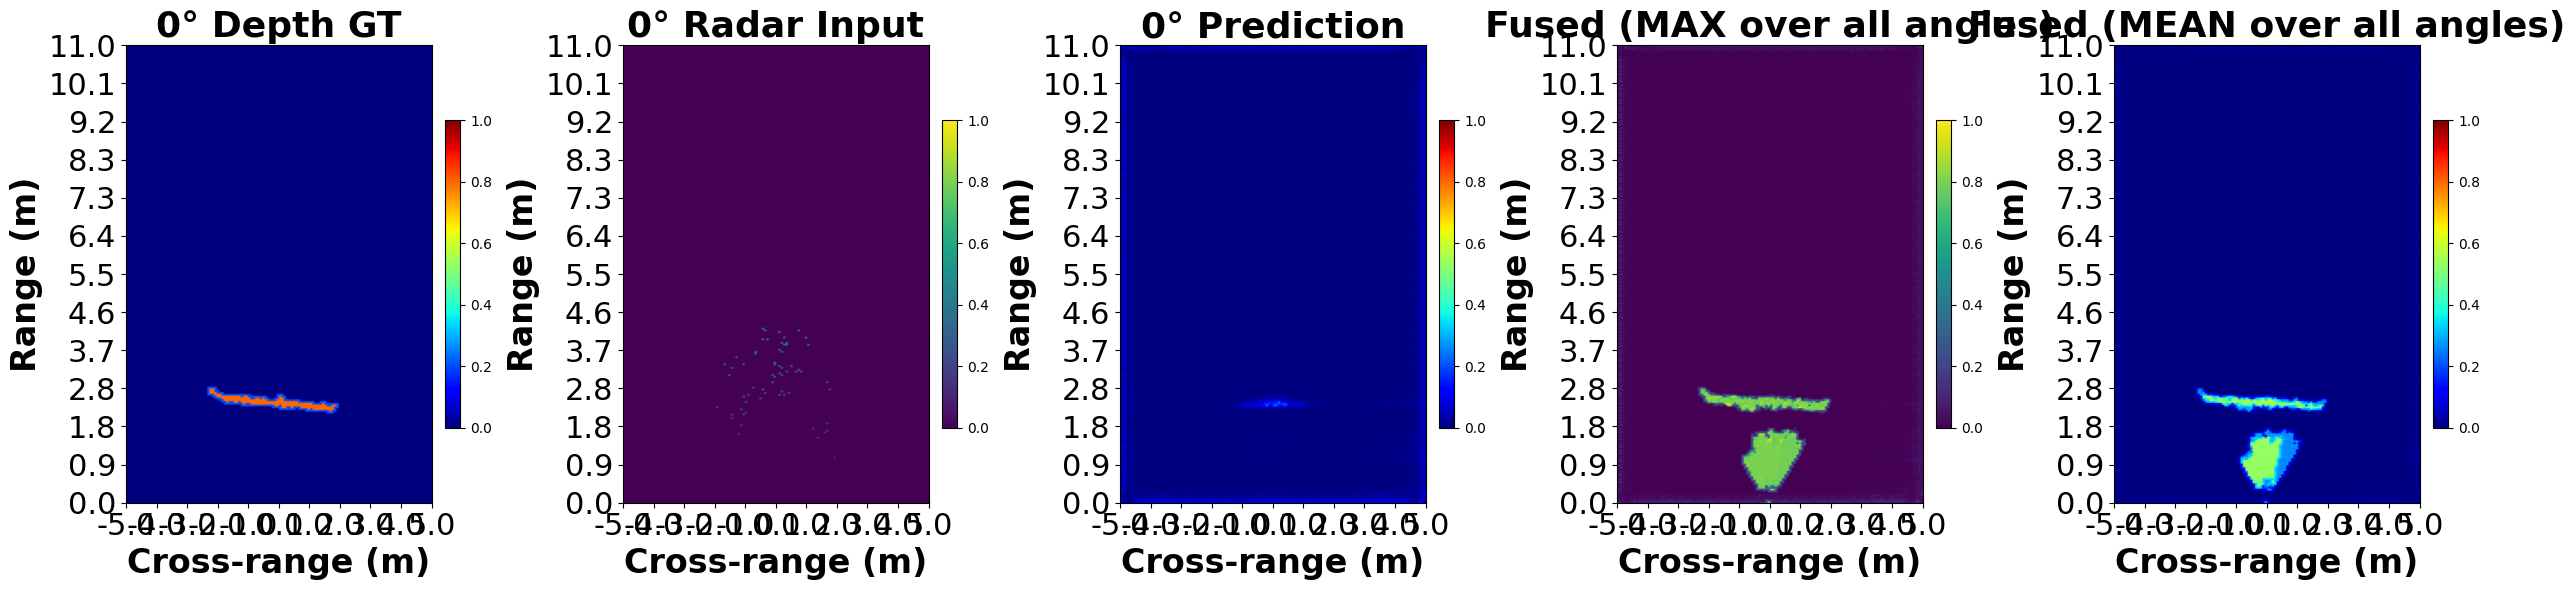

In [ ]:
import os
import glob
import pickle
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ============================
# CONSTANTS (must match training)
# ============================
NUM_RANGE_BINS = 256
H = NUM_RANGE_BINS
W = 128
RANGE_RESOLUTION_M = 0.043
MAX_RANGE_M = NUM_RANGE_BINS * RANGE_RESOLUTION_M

X_MIN_M, X_MAX_M = -5.0, 5.0

# ============================
# NORMALIZATION
# ============================
def normalize_data(x):
    """Map [0,1] → [-1,1] (same as training)."""
    return (x - 0.5) * 2.0

def denormalize_data(x):
    """Map [-1,1] → [0,1] for visualization."""
    return (x + 1.0) / 2.0

# ============================
# LOAD RADAR FRAMES FOR ONE ANGLE
# ============================
def load_radar_bev(radar_dir):
    """
    Load radar BEV images from a folder:
    expects files named like frame_*_image.npy
    returns array of shape (N, H, W, 1)
    """
    radar_files = sorted(glob.glob(os.path.join(radar_dir, "frame_*_image.npy")))
    if not radar_files:
        raise FileNotFoundError(f"No radar frames found in {radar_dir}")
    radar = [np.load(f).astype(np.float32) for f in radar_files]
    radar = np.stack(radar, axis=0)[..., None]  # (N,H,W,1)
    print(f"Loaded {len(radar_files)} radar frames from {radar_dir}")
    return radar

# ============================
# DEPTH PCD TO BEV
# ============================
def depth_pcd_to_bev(
    pcd,
    H_bev=H,
    W_bev=W,
    x_range=(X_MIN_M, X_MAX_M),
    height_min=-0.2,
    height_max=0.2,
    z_min_valid=1.8    # remove near blob near radar
):
    """
    Convert depth point cloud to BEV occupancy-like map in [0,1].
    pcd: dict with 'f0' (X), 'f1' (Y), 'f2' (Z)
    """
    X = pcd["f0"]
    Y = pcd["f1"]
    Z = pcd["f2"]

    mask = (
        (X >= x_range[0]) & (X <= x_range[1]) &
        (Z >= 0) & (Z <= MAX_RANGE_M) &
        (Y >= height_min) & (Y <= height_max)
    )
    # remove near-range blob
    mask = mask & (Z >= z_min_valid)

    X = X[mask]
    Z = Z[mask]

    bev = np.zeros((H_bev, W_bev), dtype=np.float32)
    if X.size == 0:
        return bev

    x_bins = np.linspace(x_range[0], x_range[1], W_bev)
    x_idx = np.digitize(X, x_bins) - 1
    z_idx = (Z / RANGE_RESOLUTION_M).astype(int)

    valid = (
        (x_idx >= 0) & (x_idx < W_bev) &
        (z_idx >= 0) & (z_idx < H_bev)
    )

    for x, z in zip(x_idx[valid], z_idx[valid]):
        for dx in [-1,0,1]:
            for dz in [-1,0,1]:
                nx = x + dx
                nz = z + dz
                if 0 <= nx < W_bev and 0 <= nz < H_bev:
                    weight = 0.8 if (dx == 0 and dz == 0) else 0.2
                    bev[nz, nx] = max(bev[nz, nx], weight)

    return bev

# ============================
# SIMPLE PLOTTING HELPER
# ============================
def show(ax, img, title, cmap='jet'):
    im = ax.imshow(
        img,
        cmap=cmap,
        origin='lower',
        extent=[X_MIN_M, X_MAX_M, 0, MAX_RANGE_M],
        aspect='auto',
        vmin=0, vmax=1
    )
    
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Cross-range (m)")
    ax.set_ylabel("Range (m)")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# ============================
# MULTI-ANGLE VIS + FUSION
# ============================
def visualize_angles_and_fusion(
    radar_imgs_dict,    # dict: angle_label -> radar array (N,H,W,1), normalized
    depth_bev_dict,     # dict: angle_label -> depth BEV array (N,H,W,1), normalized
    model_paths,        # dict: angle_label -> .h5 model path
    angle_labels,       # ordered list of labels, e.g. ["-30°","-15°","0°","+15°","+30°"]
    ref_label="0°",     # which label is the 0° reference
    idx=0,
    save_dir="beam_angle_output"
):
    os.makedirs(save_dir, exist_ok=True)

    # ---------- Determine max usable index across all angles ----------
    counts = []
    for lbl in angle_labels:
        n_radar = radar_imgs_dict[lbl].shape[0]
        n_depth = depth_bev_dict[lbl].shape[0]
        n_common = min(n_radar, n_depth)
        counts.append(n_common)
    max_idx = min(counts) - 1
    if idx > max_idx:
        print(f"Requested idx={idx}, but max common index is {max_idx}. Using {max_idx}.")
        idx = max_idx
    print(f"Using frame index: {idx}")

    # ---------- Load models ----------
    models = {}
    for lbl in angle_labels:
        path = model_paths[lbl]
        print(f"Loading model for {lbl}: {path}")
        models[lbl] = tf.keras.models.load_model(path)

    # ---------- Predict per-angle + gather visuals ----------
    preds_denorm = {}   # label -> (H,W) in [0,1]
    radar_vis_dict = {} # label -> (H,W) radar in [0,1]
    gt_vis_dict = {}    # label -> (H,W) GT in [0,1]

    for lbl in angle_labels:
        radar_img = radar_imgs_dict[lbl][idx]      # (H,W,1) normalized
        depth_img = depth_bev_dict[lbl][idx]       # (H,W,1) normalized

        inp = np.expand_dims(radar_img, 0)         # (1,H,W,1)
        pred_norm = models[lbl].predict(inp, verbose=0)[0, ..., 0]  # [-1,1]

        preds_denorm[lbl] = denormalize_data(pred_norm)
        radar_vis_dict[lbl] = denormalize_data(radar_img[..., 0])
        gt_vis_dict[lbl] = denormalize_data(depth_img[..., 0])

    # ---------- 0° reference GT & pred ----------
    gt_0_vis = gt_vis_dict[ref_label]
    pred_0_vis = preds_denorm[ref_label]
    radar_0_vis = radar_vis_dict[ref_label]

    # ---------- Fusion over all angle predictions (including 0°) ----------
    stack = np.stack([preds_denorm[l] for l in angle_labels], axis=0)  # (K,H,W)
    K = stack.shape[0]
    fused_max = np.max(stack, axis=0)
    fused_mean = np.mean(stack, axis=0)
    weights = np.ones(K) / K
    fused_weight = np.sum(stack * weights[:, None, None], axis=0)

    # =====================================================
    # FIGURE 1 — For each angle: radar, GT, pred (300 DPI)
    # =====================================================
    # num_angles = len(angle_labels)
    # fig1, axes = plt.subplots(num_angles, 3, figsize=(15, 4 * num_angles))

    # if num_angles == 1:
    #     axes = np.expand_dims(axes, axis=0)  # ensure 2D

    # for i, lbl in enumerate(angle_labels):
    #     ax_radar, ax_gt, ax_pred = axes[i]

    #     show(ax_radar, radar_vis_dict[lbl], f"{lbl} Radar Input", cmap="viridis")
    #     show(ax_gt,    gt_vis_dict[lbl],    f"{lbl} Depth GT",   cmap="jet")
    #     show(ax_pred,  preds_denorm[lbl],   f"{lbl} Prediction", cmap="jet")

    # plt.tight_layout()
    # out1 = os.path.join(save_dir, f"1_per_angle_radar_gt_pred_idx{idx}_300dpi.png")
    # plt.savefig(out1, dpi=300, bbox_inches="tight")
    # print(f"Saved: {out1}")
    # plt.show()

    # =====================================================
    # FIGURE 2 — 0° GT vs 0° pred vs fused (300 DPI)
    # =====================================================
    fig2, ax2 = plt.subplots(1, 5, figsize=(25, 6))

    show(ax2[0], gt_0_vis, "0° Depth GT", cmap="jet")
    show(ax2[1], radar_0_vis, "0° Radar Input", cmap="viridis")
    show(ax2[2], pred_0_vis, "0° Prediction", cmap="jet")
    show(ax2[3], fused_max, "Fused (MAX over all angles)", cmap="jet")
    show(ax2[4], fused_mean, "Fused (MEAN over all angles)", cmap="jet")
    # if you also want weighted:
    # show(ax2[5], fused_weight, "Fused (Weighted)", cmap="jet")

    plt.tight_layout()
    out2 = os.path.join(save_dir, f"2_fusion_vs_0deg_idx{idx}_300dpi.png")
    plt.savefig(out2, dpi=300, bbox_inches="tight")
    print(f"Saved: {out2}")
    plt.show()

    return {
        "idx_used": idx,
        "preds_per_angle": preds_denorm,
        "fused_max": fused_max,
        "fused_mean": fused_mean,
        "fused_weight": fused_weight,
        "gt_0": gt_0_vis,
        "pred_0": pred_0_vis
    }

# ============================
# MAIN
# ============================
def main():
    # --------------------------------------------------
    # 1) CONFIGURE YOUR ANGLES, FOLDERS, DEPTH PKLs, MODELS
    # --------------------------------------------------
    # Example with 5 angles:
    ANGLE_LABELS = ["-15°", "0°", "+15°"]

    # Radar directories per angle (2D PCD → BEV npy files)
    RADAR_DIRS = {
        "-15°": "./radar_pcd_frames_15N",
        "0°":   "./radar_pcd_frames_1",
        "+15°": "./radar_pcd_frames_15P"
    }

    # Depth GT PKL per angle
    DEPTH_PKLS = {
        "-15°": "./15n_2.pkl",
        "0°":   "./0_4.pkl",
        "+15°": "./15p_2.pkl"
    }

    # Models per angle
    MODEL_PATHS = {
        "-15°": "./final_generator_improved_15N.h5",
        "0°":   "./final_generator_improved.h5",
        "+15°": "./final_generator_improved_15P.h5"
    }

    # Which label corresponds to 0° reference
    REF_LABEL = "0°"

    # Frame index you want to visualize
    idx = 120

    # --------------------------------------------------
    # 2) LOAD RADAR + DEPTH FOR EACH ANGLE
    # --------------------------------------------------
    radar_imgs_dict = {}
    depth_bev_dict = {}
    common_counts = []

    for lbl in ANGLE_LABELS:
        print(f"\n=== Loading data for angle {lbl} ===")

        # Radar
        radar_imgs = load_radar_bev(RADAR_DIRS[lbl])
        # Depth GT
        with open(DEPTH_PKLS[lbl], "rb") as f:
            depth_data = pickle.load(f)  # list of (pcd, t)

        depth_bev_list = [depth_pcd_to_bev(pcd) for pcd, _ in depth_data]
        depth_bev = np.array(depth_bev_list)[..., None]  # (N_depth,H,W,1)

        # Align lengths for this angle
        n_common = min(radar_imgs.shape[0], depth_bev.shape[0])
        radar_imgs = radar_imgs[:n_common]
        depth_bev = depth_bev[:n_common]

        print(f"  Common frames for {lbl}: {n_common}")
        if n_common == 0:
            raise RuntimeError(f"No overlapping frames for angle {lbl} (radar/depth mismatch).")

        # Normalize
        radar_imgs = normalize_data(radar_imgs)
        depth_bev = normalize_data(depth_bev)

        radar_imgs_dict[lbl] = radar_imgs
        depth_bev_dict[lbl] = depth_bev
        common_counts.append(n_common)

    global_min_frames = min(common_counts)
    print(f"\nGlobal minimum common frames across all angles: {global_min_frames}")

    if idx >= global_min_frames:
        print(f"Requested idx={idx} is out of range. Using {global_min_frames-1} instead.")
        idx = global_min_frames - 1

    # --------------------------------------------------
    # 3) VISUALIZE PER-ANGLE + FUSION vs 0°
    # --------------------------------------------------
    visualize_angles_and_fusion(
        radar_imgs_dict=radar_imgs_dict,
        depth_bev_dict=depth_bev_dict,
        model_paths=MODEL_PATHS,
        angle_labels=ANGLE_LABELS,
        ref_label=REF_LABEL,
        idx=idx,
        save_dir="beam_angle_output"
    )

if __name__ == "__main__":
    main()


FINAL


Loaded 500 radar frames from ./radar_pcd_frames_30N
Loaded 500 radar frames from ./radar_pcd_frames_15N
Loaded 500 radar frames from ./radar_pcd_frames_1
Loaded 500 radar frames from ./radar_pcd_frames_15P
Loaded 500 radar frames from ./radar_pcd_frames_30P

============== WALL MASK ==============
Wall rows: 52 → 58
Wall range: 2.24m → 2.49m


Using frame index 49



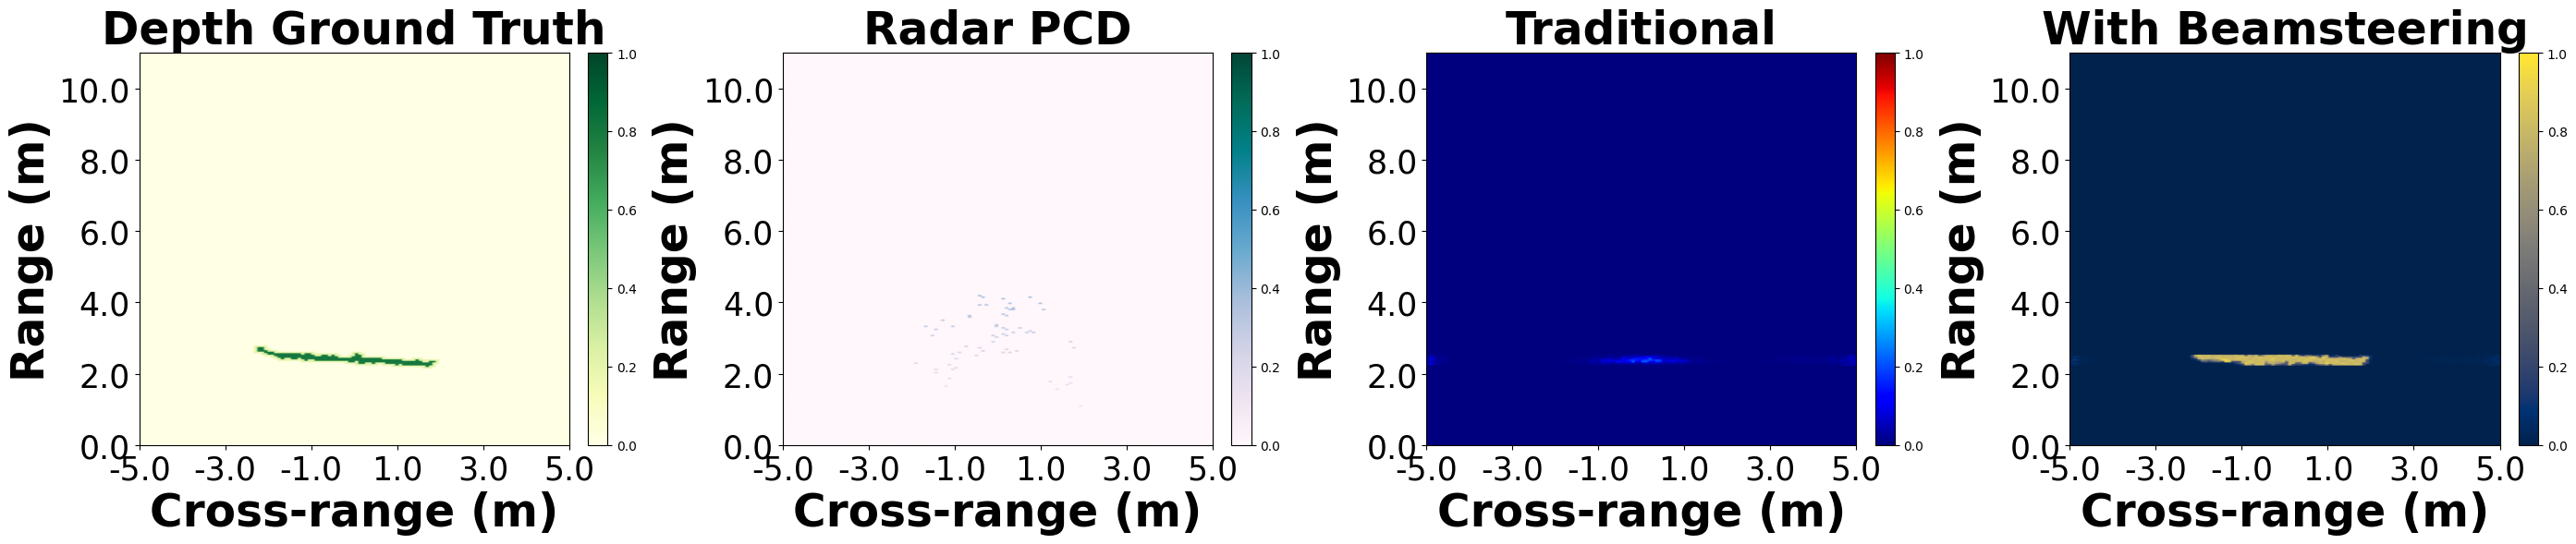

In [79]:
import os
import glob
import pickle
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ============================
# CONSTANTS
# ============================
NUM_RANGE_BINS = 256
H = NUM_RANGE_BINS
W = 128
RANGE_RESOLUTION_M = 0.043
MAX_RANGE_M = NUM_RANGE_BINS * RANGE_RESOLUTION_M

X_MIN_M, X_MAX_M = -5.0, 5.0


# ============================
# NORMALIZATION
# ============================
def normalize_data(x):
    return (x - 0.5) * 2.0        # [0,1] → [-1,1]

def denormalize_data(x):
    return (x + 1.0) / 2.0        # [-1,1] → [0,1]


# ============================
# LOAD RADAR FRAMES
# ============================
def load_radar_bev(radar_dir):
    radar_files = sorted(glob.glob(os.path.join(radar_dir, "frame_*_image.npy")))
    if not radar_files:
        raise FileNotFoundError(f"No radar frames in {radar_dir}")
    radar = [np.load(f).astype(np.float32) for f in radar_files]
    radar = np.stack(radar, axis=0)[..., None]  # (N,H,W,1)
    print(f"Loaded {len(radar_files)} radar frames from {radar_dir}")
    return radar


# ============================
# DEPTH PCD → BEV MAP
# ============================
def depth_pcd_to_bev(
    pcd,
    H_bev=H,
    W_bev=W,
    x_range=(X_MIN_M, X_MAX_M),
    height_min=-0.2,
    height_max=0.2,
    z_min_valid=1.8
):

    X = pcd["f0"]
    Y = pcd["f1"]
    Z = pcd["f2"]

    mask = (
        (X >= x_range[0]) & (X <= x_range[1]) &
        (Z >= 0) & (Z <= MAX_RANGE_M) &
        (Y >= height_min) & (Y <= height_max)
    )

    mask = mask & (Z >= z_min_valid)   # remove floor blob

    X = X[mask]
    Z = Z[mask]

    bev = np.zeros((H_bev, W_bev), dtype=np.float32)

    if X.size == 0:
        return bev

    x_bins = np.linspace(x_range[0], x_range[1], W_bev)
    x_idx = np.digitize(X, x_bins) - 1
    z_idx = (Z / RANGE_RESOLUTION_M).astype(int)

    valid = (
        (x_idx >= 0) & (x_idx < W_bev) &
        (z_idx >= 0) & (z_idx < H_bev)
    )

    for x, z in zip(x_idx[valid], z_idx[valid]):
        for dx in [-1,0,1]:
            for dz in [-1,0,1]:
                nx, nz = x+dx, z+dz
                if 0 <= nx < W_bev and 0 <= nz < H_bev:
                    weight = 0.8 if (dx==0 and dz==0) else 0.2
                    bev[nz, nx] = max(bev[nz, nx], weight)

    return bev


# ============================
# WALL MASK (AUTO-DETECTED)
# ============================
def compute_wall_mask_from_depth(depth_bev_0deg, RANGE_RESOLUTION_M):
    """
    depth_bev_0deg must be normalized [-1,1], so convert to [0,1]
    """
    depth_01 = (depth_bev_0deg + 1) / 2.0

    vertical_profile = np.sum(depth_01, axis=1)

    peak_row = np.argmax(vertical_profile)
    delta = 3   # wall thickness
    r_min_idx = max(0, peak_row - delta)
    r_max_idx = min(H - 1, peak_row + delta)

    mask = np.zeros((H, W), dtype=np.float32)
    mask[r_min_idx:r_max_idx+1, :] = 1.0

    print("\n============== WALL MASK ==============")
    print(f"Wall rows: {r_min_idx} → {r_max_idx}")
    print(f"Wall range: {r_min_idx*RANGE_RESOLUTION_M:.2f}m → {r_max_idx*RANGE_RESOLUTION_M:.2f}m")
    print("========================================\n")

    return mask


# ============================
# SHOW FUNCTION
# ============================
def show(ax, img, title, cmap='jet'):
    im = ax.imshow(
        img,
        cmap=cmap,
        origin='lower',
        extent=[X_MIN_M, X_MAX_M, 0, MAX_RANGE_M],
        aspect='auto',
        vmin=0, vmax=1
    )
    # Example: ticks every 1 meter in cross-range
    xticks = np.arange(X_MIN_M, X_MAX_M + 0.1, 2.0)

    # Example: ticks every 1 meter in range direction
    yticks = np.arange(0, MAX_RANGE_M + 0.1, 2.0)

    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.set_xticklabels([f"{x:.1f}" for x in xticks], fontsize=25)
    ax.set_yticklabels([f"{y:.1f}" for y in yticks], fontsize=25)


    ax.set_title(title, fontsize=35, fontweight="bold")
    ax.set_xlabel("Cross-range (m)", fontsize=35, fontweight='bold')
    ax.set_ylabel("Range (m)", fontsize=35, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


# ============================
# MULTI-ANGLE VISUALIZATION + FUSION
# ============================
def visualize_angles_and_fusion(
    radar_imgs_dict,
    depth_bev_dict,
    model_paths,
    angle_labels,
    wall_mask,
    ref_label="0°",
    idx=0,
    save_dir="beam_angle_output"
):
    os.makedirs(save_dir, exist_ok=True)

    # determine allowed index
    counts = [min(radar_imgs_dict[l].shape[0], depth_bev_dict[l].shape[0])
              for l in angle_labels]
    max_idx = min(counts) - 1
    if idx > max_idx:
        idx = max_idx

    print(f"\nUsing frame index {idx}\n")

    # load models
    models = {lbl: tf.keras.models.load_model(model_paths[lbl])
              for lbl in angle_labels}

    preds_denorm = {}
    radar_vis = {}
    gt_vis = {}

    # per-angle predictions
    for lbl in angle_labels:
        radar_img = radar_imgs_dict[lbl][idx]
        depth_img = depth_bev_dict[lbl][idx]

        pred_norm = models[lbl].predict(np.expand_dims(radar_img, 0), verbose=0)[0, ..., 0]

        pred_01 = denormalize_data(pred_norm)

        # WALL MASK APPLICATION  (CRUCIAL!)
        pred_01 *= wall_mask

        preds_denorm[lbl] = pred_01
        radar_vis[lbl] = denormalize_data(radar_img[..., 0])
        gt_vis[lbl] = denormalize_data(depth_img[..., 0])

    # reference 0°
    gt_0 = gt_vis[ref_label]
    pred_0 = preds_denorm[ref_label]
    radar_0 = radar_vis[ref_label]

    # fusion stack
    stack = np.stack([preds_denorm[l] for l in angle_labels], axis=0)
    fused_max = np.max(stack, axis=0)
    fused_mean = np.mean(stack, axis=0)

    # ----------------------------------------------------------
    # FIGURE 1 — Per-angle: radar, GT, prediction
    # ----------------------------------------------------------
    # fig1, axes = plt.subplots(len(angle_labels), 3, figsize=(15, 4 * len(angle_labels)))

    # if len(angle_labels) == 1:
    #     axes = np.expand_dims(axes, 0)

    # for i, lbl in enumerate(angle_labels):
    #     show(axes[i,0], radar_vis[lbl], f"{lbl} Radar", cmap='viridis')
    #     show(axes[i,1], gt_vis[lbl],    f"{lbl} Depth GT", cmap='jet')
    #     show(axes[i,2], preds_denorm[lbl], f"{lbl} Prediction", cmap='jet')

    # plt.tight_layout()
    # plt.savefig(os.path.join(save_dir, f"1_per_angle_idx{idx}_300dpi.png"),
    #             dpi=300, bbox_inches='tight')
    # plt.show()

    # ----------------------------------------------------------
    # FIGURE 2 — 0° GT + 0° Pred + Fused
    # ----------------------------------------------------------
    fig2, axes = plt.subplots(1, 4, figsize=(28, 6))

    show(axes[0], gt_0, "Depth Ground Truth", cmap='YlGn')
    show(axes[1], radar_0, "Radar PCD", cmap='PuBuGn')
    show(axes[2], pred_0, "Traditional", cmap='jet')
    show(axes[3], fused_max, "With Beamsteering", cmap='cividis')
    #show(axes[4], fused_mean, "Fused (MEAN)", cmap='jet')

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"2_fusion_vs_0deg_idx{idx}_600dpi.png"),
                dpi=600, bbox_inches='tight')
    plt.show()

    return {
        "idx_used": idx,
        "preds": preds_denorm,
        "fused_max": fused_max,
        "fused_mean": fused_mean,
        "gt_0": gt_0,
        "pred_0": pred_0
    }


# ============================
# MAIN
# ============================
def main():

    ANGLE_LABELS = ["-30°", "-15°", "0°", "+15°", "+30°"]

    RADAR_DIRS = {
        "-30°": "./radar_pcd_frames_30N",
        "-15°": "./radar_pcd_frames_15N",
        "0°":   "./radar_pcd_frames_1",
        "+15°": "./radar_pcd_frames_15P",
        "+30°": "./radar_pcd_frames_30P"
    }

    DEPTH_PKLS = {
        "-30°": "./30n_2.pkl",
        "-15°": "./15n_2.pkl",
        "0°":   "./0_4.pkl",
        "+15°": "./15p_2.pkl",
        "+30°": "./30p_2.pkl"
    }

    MODEL_PATHS = {
        "-30°": "./final_generator_improved_30N.h5",
        "-15°": "./final_generator_improved_15N.h5",
        "0°":   "./final_generator_improved.h5",
        "+15°": "./final_generator_improved_15P.h5",
        "+30°": "./final_generator_improved_30P.h5"
    }

    REF_LABEL = "0°"
    idx = 120

    radar_imgs_dict = {}
    depth_bev_dict = {}
    frame_counts = []

    # load all angle data
    for lbl in ANGLE_LABELS:
        radar = load_radar_bev(RADAR_DIRS[lbl])

        with open(DEPTH_PKLS[lbl], "rb") as f:
            depth_data = pickle.load(f)

        depth_bev = np.array([depth_pcd_to_bev(p) for p, _ in depth_data])[..., None]

        n_common = min(radar.shape[0], depth_bev.shape[0])
        radar = radar[:n_common]
        depth_bev = depth_bev[:n_common]

        radar_imgs_dict[lbl] = normalize_data(radar)
        depth_bev_dict[lbl] = normalize_data(depth_bev)

        frame_counts.append(n_common)

    global_min = min(frame_counts)
    if idx >= global_min:
        idx = global_min - 1

    # WALL MASK from 0° depth
    depth_0_first = depth_bev_dict["0°"][0, ..., 0]
    wall_mask = compute_wall_mask_from_depth(depth_0_first, RANGE_RESOLUTION_M)

    # visualization + fusion
    visualize_angles_and_fusion(
        radar_imgs_dict,
        depth_bev_dict,
        MODEL_PATHS,
        ANGLE_LABELS,
        wall_mask,
        REF_LABEL,
        idx,
        save_dir="beam_angle_output"
    )


if __name__ == "__main__":
    main()


In [48]:
import numpy as np
import tensorflow as tf
import pickle
import glob
import os

# ==============================
# CONSTANTS (same as training)
# ==============================
NUM_RANGE_BINS = 256
H = NUM_RANGE_BINS
W = 128
RANGE_RESOLUTION_M = 0.043
MAX_RANGE_M = RANGE_RESOLUTION_M * NUM_RANGE_BINS
X_MIN_M, X_MAX_M = -5.0, 5.0
HEIGHT_MIN, HEIGHT_MAX = -0.2, 0.2


# ==============================
# NORMALIZATION (same as training)
# ==============================
def normalize_data(x):
    return (x - 0.5) * 2.0    # [0,1] → [-1,1]


# ==============================
# DEPTH PCD → BEV (same as training)
# ==============================
def depth_pcd_to_bev(
    pcd,
    H_bev=H,
    W_bev=W,
    x_range=(X_MIN_M, X_MAX_M),
    height_min=HEIGHT_MIN,
    height_max=HEIGHT_MAX
):

    X = pcd["f0"]
    Y = pcd["f1"]
    Z = pcd["f2"]

    mask = (
        (X >= x_range[0]) & (X <= x_range[1]) &
        (Z >= 0) & (Z <= MAX_RANGE_M) &
        (Y >= height_min) & (Y <= height_max)
    )

    X = X[mask]
    Z = Z[mask]

    bev = np.zeros((H_bev, W_bev), dtype=np.float32)

    if X.size == 0:
        return bev

    x_bins = np.linspace(x_range[0], x_range[1], W_bev)
    x_idx = np.digitize(X, x_bins) - 1
    z_idx = (Z / RANGE_RESOLUTION_M).astype(int)

    valid = (
        (x_idx >= 0) & (x_idx < W_bev) &
        (z_idx >= 0) & (z_idx < H_bev)
    )

    for x, z in zip(x_idx[valid], z_idx[valid]):
        for dx in [-1, 0, 1]:
            for dz in [-1, 0, 1]:
                nx, nz = x + dx, z + dz
                if 0 <= nx < W_bev and 0 <= nz < H_bev:
                    weight = 0.8 if (dx == 0 and dz == 0) else 0.2
                    bev[nz, nx] = max(bev[nz, nx], weight)

    return bev


# ==============================
# PATHS FOR ALL ANGLES
# ==============================
MODEL_PATHS = {
    "-30°": "./best_generator_improved_30N.h5",
    "-15°": "./best_generator_improved_15N.h5",
    "0°":   "./best_generator_improved_0_4.h5",
    "+15°": "./best_generator_improved_15P.h5",
    "+30°": "./best_generator_improved_30P.h5"
}

RADAR_DIRS = {
    "-30°": "./radar_pcd_frames_30N",
    "-15°": "./radar_pcd_frames_15N",
    "0°":   "./radar_pcd_frames_1",
    "+15°": "./radar_pcd_frames_15P",
    "+30°": "./radar_pcd_frames_30P"
}

DEPTH_PKLS = {
    "-30°": "./30n_2.pkl",
    "-15°": "./15n_2.pkl",
    "0°":   "./0_4.pkl",
    "+15°": "./15p_2.pkl",
    "+30°": "./30p_2.pkl"
}


# ==============================
# COMPUTE MAE + MSE
# ==============================
def evaluate_mae_mse(model, radar_imgs, depth_imgs):
    # Predict
    pred = model.predict(radar_imgs, batch_size=4, verbose=1)

    # Convert from [-1,1] → [0,1]
    pred_01 = (pred + 1) / 2
    depth_01 = (depth_imgs + 1) / 2

    # Flatten
    y_true = depth_01.reshape(-1)
    y_pred = pred_01.reshape(-1)

    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred)**2)

    return mae, mse


# ==============================
# MAIN EVALUATION LOOP
# ==============================
loss_results = {}

for angle in MODEL_PATHS.keys():
    print(f"\n========== EVALUATING MODEL AT {angle} ==========\n")

    # Load model
    model = tf.keras.models.load_model(MODEL_PATHS[angle], compile=False)

    # Load radar images
    radar_files = sorted(glob.glob(os.path.join(RADAR_DIRS[angle], "frame_*_image.npy")))
    radar_imgs = np.stack([np.load(f).astype(np.float32) for f in radar_files], axis=0)
    radar_imgs = radar_imgs[..., None]

    # Load depth data
    with open(DEPTH_PKLS[angle], "rb") as f:
        depth_data = pickle.load(f)

    depth_imgs = np.array([depth_pcd_to_bev(p) for p, _ in depth_data])[..., None]

    # Sync number of frames
    n = min(len(radar_imgs), len(depth_imgs))
    radar_imgs = radar_imgs[:n]
    depth_imgs = depth_imgs[:n]

    # Normalize
    radar_imgs = normalize_data(radar_imgs)
    depth_imgs = normalize_data(depth_imgs)

    # Compute MAE & MSE
    mae, mse = evaluate_mae_mse(model, radar_imgs, depth_imgs)

    loss_results[angle] = (mae, mse)

# ==============================
# PRINT FINAL LOSS TABLE
# ==============================
print("\n================ FINAL MAE & MSE TABLE ================\n")

for angle, (mae, mse) in loss_results.items():
    print(f"{angle:>5} → MAE = {mae:.6f},   MSE = {mse:.6f}")



========== EVALUATING MODEL AT -30° ==========

13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step 

========== EVALUATING MODEL AT -15° ==========

13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 684ms/step

========== EVALUATING MODEL AT 0° ==========

13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 667ms/step

========== EVALUATING MODEL AT +15° ==========

13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step

========== EVALUATING MODEL AT +30° ==========

13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step

================ FINAL MAE & MSE TABLE ================

 -30° → MAE = 0.013112,   MSE = 0.009198
 -15° → MAE = 0.002929,   MSE = 0.001023
   0° → MAE = 0.003072,   MSE = 0.001091
 +15° → MAE = 0.013655,   MSE = 0.008611
 +30° → MAE = 0.002320,   MSE = 0.000874


In [59]:
import numpy as np
import pickle
import glob
import os
import tensorflow as tf

# ----------------------------
# Normalization (same as for MAE)
# ----------------------------
def normalize01(x):
    return (x - 0.5) * 2.0


# ----------------------------
# Compute MSE between raw radar BEV and depth BEV
# ----------------------------
def compute_raw_mse(radar_bev, depth_bev):
    radar_01  = (radar_bev + 1) / 2
    depth_01  = (depth_bev + 1) / 2
    return np.mean((radar_01 - depth_01) ** 2)


RAW_MSE_RESULTS = {}

for angle in RADAR_DIRS.keys():

    print(f"\n=== Computing RAW Radar MSE for {angle} ===")

    # Load radar frames (PCD → BEV)
    radar_files = sorted(glob.glob(os.path.join(RADAR_DIRS[angle], "frame_*_image.npy")))
    radar_bevs = np.stack([np.load(f).astype(np.float32) for f in radar_files], axis=0)[...,None]

    # Load depth frames
    with open(DEPTH_PKLS[angle], "rb") as f:
        depth_data = pickle.load(f)
    depth_bevs = np.array([depth_pcd_to_bev(p) for p,_ in depth_data])[...,None]

    # Match lengths
    n = min(len(radar_bevs), len(depth_bevs))
    radar_bevs = radar_bevs[:n]
    depth_bevs = depth_bevs[:n]

    # Normalize
    radar_bevs = normalize01(radar_bevs)
    depth_bevs = normalize01(depth_bevs)

    # Compute MSE
    mse_raw = compute_raw_mse(radar_bevs, depth_bevs)
    RAW_MSE_RESULTS[angle] = mse_raw


# Print results
print("\n========== RAW BASELINE MSE (No GAN) ==========")
for angle, m in RAW_MSE_RESULTS.items():
    print(f"{angle}: {m:.6f}")



=== Computing RAW Radar MSE for -30° ===

=== Computing RAW Radar MSE for -15° ===

=== Computing RAW Radar MSE for 0° ===

=== Computing RAW Radar MSE for +15° ===

=== Computing RAW Radar MSE for +30° ===

========== RAW BASELINE MSE (No GAN) ==========
-30°: 0.004005
-15°: 0.004093
0°: 0.003537
+15°: 0.003424
+30°: 0.003441
